<div style="background-color:#234c7d; border-radius:8px; padding:32px 40px 24px; margin-bottom:8px;">
  <h1 style="margin:0 0 6px; font-size:28px; font-weight:600; color:#C49A28; letter-spacing:-0.5px;">
    GA Image Approximation
  </h1>
  <p style="margin:0; font-size:13px; color:#a8b8d0; letter-spacing:0.5px;">
    Implementation & Analysis Notebook
  </p>
</div>

<div style="border:1.5px solid #234c7d; border-radius:8px; padding:20px 40px; margin-bottom:8px; display:flex; gap:48px;">
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Group 35 - Convergence</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Alexandra Rodrigues, 20250514 &nbsp;<br>
      Francisca Fernandes, 20250406 &nbsp;<br>
      Gonçalo Arrobas, 20250421 &nbsp;<br>
      Mariana Melo, 20250414  &nbsp;<br>
    </p>
  </div>
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Course</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Computational Intelligence for Optimization<br>
      MSc in Data Science & Advanced Analytics<br>
      Nova Information Management School (NOVA IMS)<br>
      2025/2026
    </p>
  </div>
</div>

## **<span style="color:#234c7d">Table of Contents</span>**
    
- [1. Problem Statement](#1-problem-statement) 
- [2. Representation](#2-representation)
    - [2.1. The Gene: Triangle](#21-the-gene-triangle)
    - [2.2. The Chromossome: Individual](#22-the-chromosome-individual) 
    - [2.3. Initialisation Strategies](#23-initialisation-strategies) 
- [3. Fitness Function](#3-fitness-function)
- [4. Rendering Pipeline](#4-rendering-pipeline)
- [5. Genetic Operators](#5-genetic-operators)
    - [5.1. Selection](#51-selection)
    - [5.2. Crossover](#52-crossover) 
    - [5.3. Mutation](#53-mutation) 
- [6. Evolutionary Engine](#6-evolutionary-engine)
    - [6.1. Population](#61-population)
    - [6.2. GA Engine](#62-ga-engine) 
- [7. Experimental Pipeline](#7-experimental-pipeline)
    - [7.1. Output Structure](#71-output-structure)
    - [7.2. Phase Structure](#72-phase-structure)
    - [7.3. Extended Phases](#73-extended-phases)
- [8. Results](#8-results)
    - [8.1. ](#71-output-structure)
    - [8.2. ](#72-phase-structure)
    - [8.3. ](#73-extended-phases)
    - [8.4. ](#73-extended-phases)
    - [8.5. Statistical Validation ](#85-statistical-validation)

In [33]:
import os
import re
import sys
import csv
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from scipy import stats
from scipy.ndimage import gaussian_filter
from PIL import Image, ImageDraw

from triangle import Triangle
from individual import Individual
from population import Population
from fitness import RMSEFitness
from ga import GeneticAlgorithm, GAConfig, EarlyStopping
from ga_utils import render, IMG_WIDTH, IMG_HEIGHT
from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover, BlendCrossover, BlendCrossover,SegmentShuffleCrossover 
from ga_operators.mutation import GaussianMutation, CreepMutation, ResetMutation, SwapMutation, SigmaDecayScheduler

# 1. Problem Statement

**Goal:** Reconstruct a target painting using exactly **100 semi-transparent triangles**, optimised by a Genetic Algorithm.

- **Target image:** Vermeer's *Girl with a Pearl Earring* (300 $\times$ 400 pixels, RGB)
- **Representation:** each candidate solution is an ordered stack of **100 semi-transparent triangles**, each defined by 3 vertices $(x, y) \in \mathbb{R}^2$ and an RGBA colour -> **7 continuous parameters per triangle** and a genome of **700 dimensions**.
- **Search space:** $\mathbb{R}^{700}$, continuous and non-convex, with no closed-form gradient, right for the use of Evolutionary Computation.
- **Objective:** minimise pixel-level reconstruction error between the rendered candidate and the target image (RMSE).

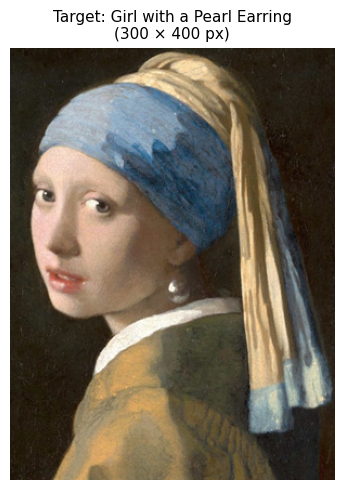

Image shape: (400, 300, 3)  |  dtype: uint8


In [ ]:
# Load target image
target = Image.open("../data/Girl_Pearl_Earing.png").convert("RGB")
target_arr = np.array(target)

fig, ax = plt.subplots(figsize=(4, 5))
ax.imshow(target_arr)
ax.axis("off")
ax.set_title("Target: Girl with a Pearl Earring\n(300 × 400 px)", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Image shape: {target_arr.shape}  |  dtype: {target_arr.dtype}")


# 2. Representation

## 2.1. The Gene: Triangle

`Triangle` is the gene-level class of the GA, implemented in `triangle.py` as an immutable dataclass following a value object pattern: it is defined entirely by its data (`vertices` and `color`), has no identity beyond those values, and is never modified after creation. The class defines the gene's data fields, validation logic, geometric helper methods, factory methods for flexible initialisation, mutation methods for vertex and colour perturbation and serialisation utilities for checkpointing.

| Field | Type | Range | Description |
|---|---|---|---|
| `vertices` | $3 \times (x, y)$ float | $[0,W)\times[0,H)$ | Triangle vertex coordinates in pixel space |
| `color` | `(R,G,B,A)` int | $[0,255]^4$ | RGB color and alpha transparency |

**Key design choices in `triangle.py`:**

- **Immutability:** `Triangle` instances are immutable (`@dataclass(frozen=True, slots=True)`), enforced at the language level. Genetic operators therefore return new instances rather than modifying existing ones in place, simplifying state management and avoiding unintended side effects during evolution.

- **Continuous vertex space:** vertex coordinates are stored as floating-point values and discretised only at render time. This enables fine-grained geometric mutations and avoids cumulative precision loss from repeated integer rounding.

- **Alpha compositing:** the alpha channel enables semi-transparent overlap between primitives. During rendering, overlapping triangles blend through alpha compositing, allowing the population to approximate smooth colour transitions rather than only piecewise-constant regions.

- **Degeneracy detection:** `is_degenerate()` computes triangle area using the shoelace formula and flags near-collinear configurations (area < 1 $px^2$). Such triangles contribute negligibly to the rendered image and may be filtered or penalised during mutation.

In [ ]:
sys.path.insert(0, "../src")
rng = np.random.default_rng(42)

# creating a triangle 
t = Triangle(
    vertices=((50.0, 80.0), (200.0, 30.0), (150.0, 250.0)),
    color=(70, 130, 180, 120)
)

print(" Triangle (gene) ")
print(f"  repr         : {t}")
print()
print(" Geometry ")
print(f"  vertices     : {t.vertices}")
print(f"  xs           : {t.xs}")
print(f"  ys           : {t.ys}")
print(f"  area         : {t.area():.1f}")
print(f"  bounding box : {t.bounding_box()}")
print(f"  degenerate   : {t.is_degenerate()}")
print()
print(" Colour ")
print(f"  color        : {t.color}  (R, G, B, A)")
print(f"  rgb          : {t.rgb}")
print(f"  alpha        : {t.alpha}")
print(f"  alpha_float  : {t.alpha_float:.3f}")
print()
print(" Immutability ")
try:
    t.color = (255, 0, 0, 255)
except Exception as e:
    print(f"  t.color = (255, 0, 0, 255)  ->  {type(e).__name__}")
    print(f"  Triangle is frozen — all operators must return new instances")

 Triangle (gene) 
  repr         : Triangle(vertices=[(50.0,80.0), (200.0,30.0), (150.0,250.0)], color=RGBA(70,130,180,120))

 Geometry 
  vertices     : ((50.0, 80.0), (200.0, 30.0), (150.0, 250.0))
  xs           : [ 50. 200. 150.]
  ys           : [ 80.  30. 250.]
  area         : 15250.0
  bounding box : (50, 30, 200, 250)
  degenerate   : False

 Colour 
  color        : (70, 130, 180, 120)  (R, G, B, A)
  rgb          : (70, 130, 180)
  alpha        : 120
  alpha_float  : 0.471

 Immutability 
  t.color = (255, 0, 0, 255)  ->  FrozenInstanceError
  Triangle is frozen — all operators must return new instances


## 2.2. The Chromosome: Individual

`Individual` is the chromosome-level class of the GA, implemented in `individual.py` following an encapsulation principle: it wraps an ordered sequence of exactly 100 `Triangle` objects and exposes only controlled interfaces for fitness access, chromosome manipulation and initialisation, hiding internal rendering and caching details from the rest of the system.

Draw order is semantically meaningful: index 0 is the bottom-most layer, index 99 is the top-most and occludes everything beneath it.

<div style="text-align:center; margin: 16px 0;">

$Individual = [Triangle_0, Triangle_1, ..., Triangle_{99}]$

</div>

This gives a total genome of $100 \times 7 = 700$ continuous parameters.

**Key design choices in `individual.py`:**

- **Lazy fitness caching:** rendering 100 alpha-composited layers is expensive. Fitness is computed once on first access and cached for the lifetime of the individual. The GA engine can call `.fitness` freely during sorting, selection and logging with zero redundant renders.
- **Immutability by design:** unlike `Triangle` which enforces immutability at the language level via `frozen=True`, `Individual` achieves it through disciplined encapsulation: the chromosome is stored as a private tuple and all crossover and mutation operators return new instances via `copy_with()` rather than modifying in place. This makes the generational loop easy to reason about — no individual is ever in an intermediate state.
- **Shared fitness function reference:**  the `FitnessFunction` object (which holds the target image array) is shared across all individuals in a population following a **flyweight** pattern, not copied. This keeps memory usage proportional to population size rather than population size × image size.

In [ ]:
rng = np.random.default_rng(42)
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

# criação
ind = Individual.random(fitness_fn, rng)
print(" Individual ")
print(f"  repr             : {ind}")
print(f"  n_triangles      : {len(ind.triangles)}")
print(f"  is_evaluated     : {ind.is_evaluated()}")

# lazy caching
fitness = ind.fitness
print(f"\n  fitness (1st access, triggers render) : {fitness:.4f}")
print(f"  is_evaluated     : {ind.is_evaluated()}")
print(f"  fitness (2nd access, from cache)      : {ind.fitness:.4f}")

# imutabilidade
ind2 = ind.copy_with(triangles=list(ind.triangles))
print(f"\n  copy_with() -> new object : {ind is ind2}")
print(f"  fitness cache not transferred : {ind2.is_evaluated()}")

 Individual 
  repr             : Individual(triangles=100, fitness=not evaluated)
  n_triangles      : 100
  is_evaluated     : False

  fitness (1st access, triggers render) : 85.4575
  is_evaluated     : True
  fitness (2nd access, from cache)      : 85.4575

  copy_with() -> new object : False
  fitness cache not transferred : False


## 2.3. Initialisation Strategies

Initialisation determines the starting point of the search.  Following the Single Responsibility Principle, initialisation logic is distributed across the two classes presented above: `Triangle` defines how individual genes are constructed and `Individual` composes them into full chromosomes.

Six strategies are implemented, each encoding a different inductive bias about what constitutes a good starting point. 

| Strategy | Geometry | Colour | Key property |
|----------|----------|--------|--------------|
| `random` | Uniform random | Uniform random | Uniform random geometry and colour; maximum diversity |
| `random_semitransparent` | Uniform random | Uniform random, $\alpha \in [30, 120]$ | Restricts $\alpha$, encouraging layering of triangles from different opacities from the beginning |
| `random_small` | Clustered ($\leq 15\%$ canvas) | Uniform random | Generates small triangles by keeping vertices within 15\% of the canvas size from each other |
| `from_grid_random_color` | $10 \times 10$ grid + Gaussian noise | Uniform random | Guaranteed spatial coverage |
| `random_sorted_alpha` | Uniform random | Uniform random | Opaque triangles placed on lower layers |
| `random_quadrant` | Constrained per $5 \times 5$ cell | Uniform random | Guarantees per-region coverage |

The strategies form a natural spectrum from fully uninformed (`random`) to increasingly structured (`from_grid_random_color`, `random_quadrant`), and from unconstrained to deliberately biased (`random_semitransparent`, `random_small`, `random_sorted_alpha`). In grid-based strategies, vertex noise ($\sigma = 0.3 \times \text{cell\_size}$ by default) is applied per individual to ensure population diversity. Without it, all chromosomes would share identical triangle positions, causing immediate premature convergence.

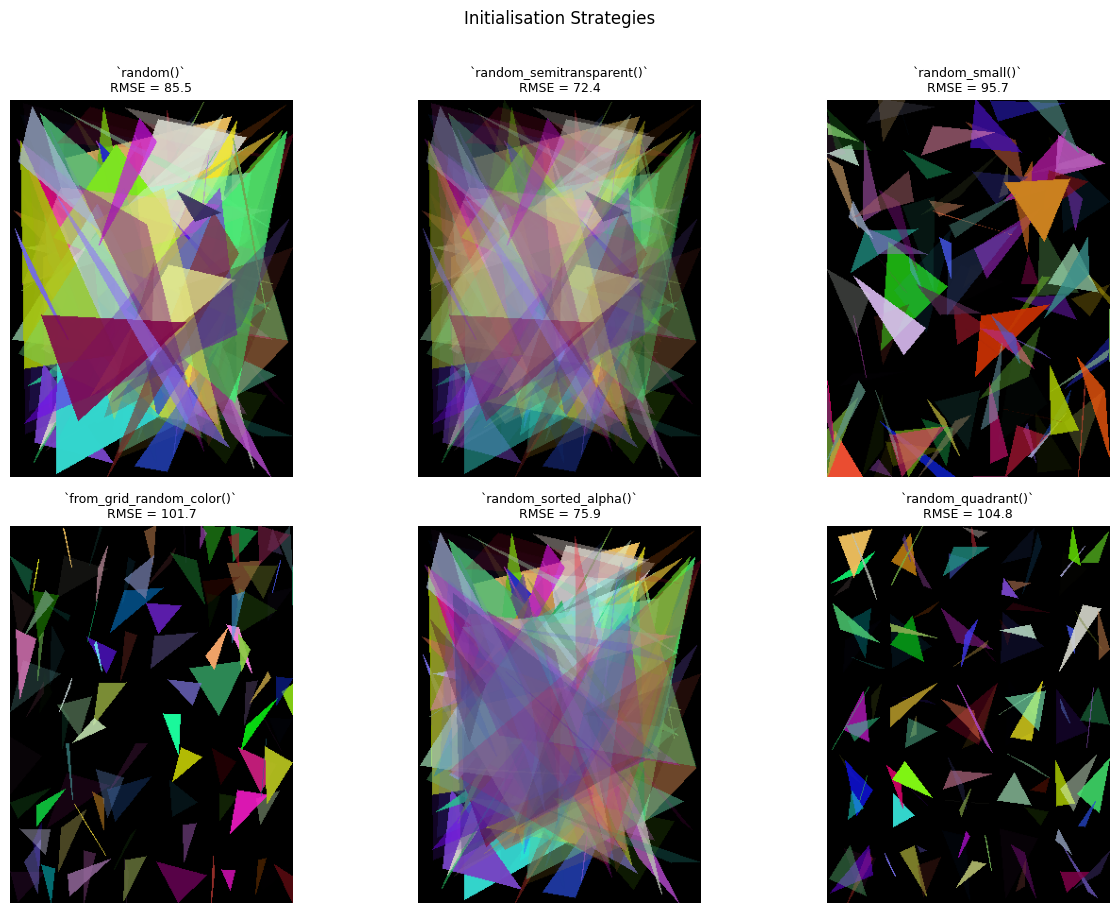

In [ ]:
sys.path.insert(0, "../src")

rng_seed = 42
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

strategies = [
    ("random",                  lambda rng: Individual.random(fitness_fn, rng)),
    ("random_semitransparent",  lambda rng: Individual.random_semitransparent(fitness_fn, rng)),
    ("random_small",            lambda rng: Individual.random_small(fitness_fn, rng)),
    ("from_grid_random_color",  lambda rng: Individual.from_grid_random_color(fitness_fn, rng)),
    ("random_sorted_alpha",     lambda rng: Individual.random_sorted_alpha(fitness_fn, rng)),
    ("random_quadrant",         lambda rng: Individual.random_quadrant(fitness_fn, rng)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, factory) in zip(axes, strategies):
    rng = np.random.default_rng(rng_seed)
    ind = factory(rng)
    rendered = render(ind.triangles)
    rmse = ind.fitness

    ax.imshow(rendered)
    ax.set_title(f"`{name}()`\nRMSE = {rmse:.1f}", fontsize=9, pad=6)
    ax.axis("off")

plt.suptitle("Initialisation Strategies", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# 3. Fitness Function

The fitness function quantifies how closely a candidate solution approximates the target image. It is implemented in `fitness.py` following the Strategy pattern: `FitnessFunction` is an abstract base class (ABC) that defines a single interface - `evaluate(candidate) -> float` - and the GA engine depends only on this abstraction, making the metric swappable without touching any other component.

**`RMSEFitness`** is the metric required by the project specification and used throughout our experiments:

$$\text{RMSE} = \sqrt{\frac{1}{H \times W \times C} \sum_{h,w,c} \left( I_{\text{rendered}}[h,w,c] - I_{\text{target}}[h,w,c] \right)^2}$$

The GA **minimises** this value: a perfect reconstruction scores 0, with a theoretical maximum of 255. The target image is converted to `float32` once at construction time and shared across all evaluations via the **flyweight** pattern, avoiding repeated casting in the computational hot path.

# 4. Rendering Pipeline

The rendering pipeline is the bridge between representation and fitness evaluation, converting a chromosome into a pixel array that can be compared against the target. It is implemented in `ga_utils.py`, which also serves as the single source of truth for canvas dimensions (`IMG_WIDTH = 300`, `IMG_HEIGHT = 400`). All other modules import these constants from here rather than hardcoding values.

The core function is `render()`, which follows a sequential layered compositing approach:


1. Initialise a solid black RGBA canvas ($300\times 400$ px)
2. For each triangle i in [0 ... 99]: 

   a. Create a blank transparent RGBA layer (same size as canvas)

   b. Draw the filled triangle onto that layer (PIL ImageDraw.polygon)- float vertices are rounded to integers only at this point

   c. Alpha-composite the layer onto the canvas (Porter-Duff "over"): 
         $out_RGB = \alpha \times src_RGB + (1 - \alpha) · dst_RGB4$

3. Convert final RGBA canvas -> RGB uint8 numpy array


**Key design choices in `ga_utils.py`:**

- **Per-triangle layer compositing:** PIL's `ImageDraw.polygon()` paints flat colour with no native alpha blending. To achieve true per-triangle transparency, each triangle is drawn onto its own blank RGBA layer and composited onto the canvas. This is the only technically correct approach, at the cost of one PIL image allocation per triangle per render.

- **Late vertex rounding:** float coordinates stored in `Triangle` are rounded to integer pixel positions only inside `render()`, at draw time. This preserves the full precision of continuous-space mutation throughout evolution.

- **RGB output only:** the final canvas drops the alpha channel before returning, since `FitnessFunction.evaluate()` operates on RGB arrays matched against the RGB target. Alpha is internal to the rendering process.

The module also provides I/O utilities (`load_target`, `save_render`), checkpoint helpers (`triangles_to_json`, `triangles_from_json`) and visualisation helpers (`side_by_side`, `render_triangles_pil`) used throughout the experimental pipeline.

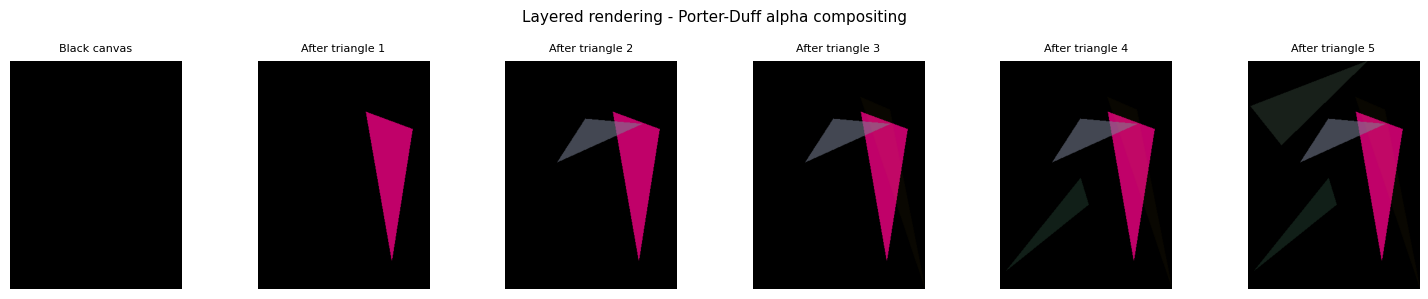

In [31]:
W, H = 300, 400
rng = np.random.default_rng(7)
demo_tris = [Triangle.random(W, H, rng) for _ in range(5)]

canvas = Image.new("RGBA", (W, H), (0, 0, 0, 255))
snapshots = [np.array(canvas.convert("RGB"))]

for tri in demo_tris:
    layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    verts_px = [(int(round(x)), int(round(y))) for x, y in tri.vertices]
    ImageDraw.Draw(layer).polygon(verts_px, fill=tri.color)
    canvas = Image.alpha_composite(canvas, layer)
    snapshots.append(np.array(canvas.convert("RGB")))

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, (snap, ax) in enumerate(zip(snapshots, axes)):
    ax.imshow(snap); ax.axis("off")
    ax.set_title(f"After triangle {i}" if i > 0 else "Black canvas", fontsize=8)
plt.suptitle("Layered rendering - Porter-Duff alpha compositing", fontsize=11)
plt.tight_layout()
plt.show()


# 5. Genetic Operators

The genetic operators define how the population evolves from one generation to the next. All three operator families - selection, crossover and mutation - follow the Strategy pattern: each is defined by an abstract base class (ABC) with a single interface method and the GA engine depends exclusively on that abstraction. Concrete strategies are injected at construction time, making any combination of operators possible without modifying the engine.

All operators are stateless between calls, being the only mutable state RNG, which is always supplied by the caller. This makes them safe to reuse across generations and trivially testable in isolation.

## 5.1. Selection

Selection determines which individuals become parents for the next generation, directly governing the **exploration/exploitation trade-off**: high selection pressure accelerates convergence but risks premature convergence to a local optimum; low pressure preserves diversity but slows progress.

Three strategies are implemented in `selection.py`:

| Operator | Mechanism | Pressure | Key property |
|----------|-----------|----------|--------------|
| `TournamentSelection(k)` | Sample $k$ individuals, return the best | Controlled by $k$ | Robust, no fitness scaling required |
| `RankSelection(sp)` |Assigns probabilities by fitness rank rather than raw value | Controlled by $sp \in (1, 2]$ | Stable pressure regardless of fitness distribution |


**`TournamentSelection`** is the baseline choice. It requires no fitness scaling, is robust to outliers (a single very fit individual cannot dominate the pool) and exposes a single interpretable parameter: the tournament size $k$:

- $k = 2$: low pressure, preserves diversity
- $k = 3$: moderate pressure *(baseline)*
- $k = 5, 10$: increasing pressure, faster convergence but higher risk of premature convergence

**`RankSelection`** assigns selection probabilities based on fitness rank rather than raw values. It is particularly useful in later generations when fitness values cluster tightly and roulette-style selection would become nearly uniform.


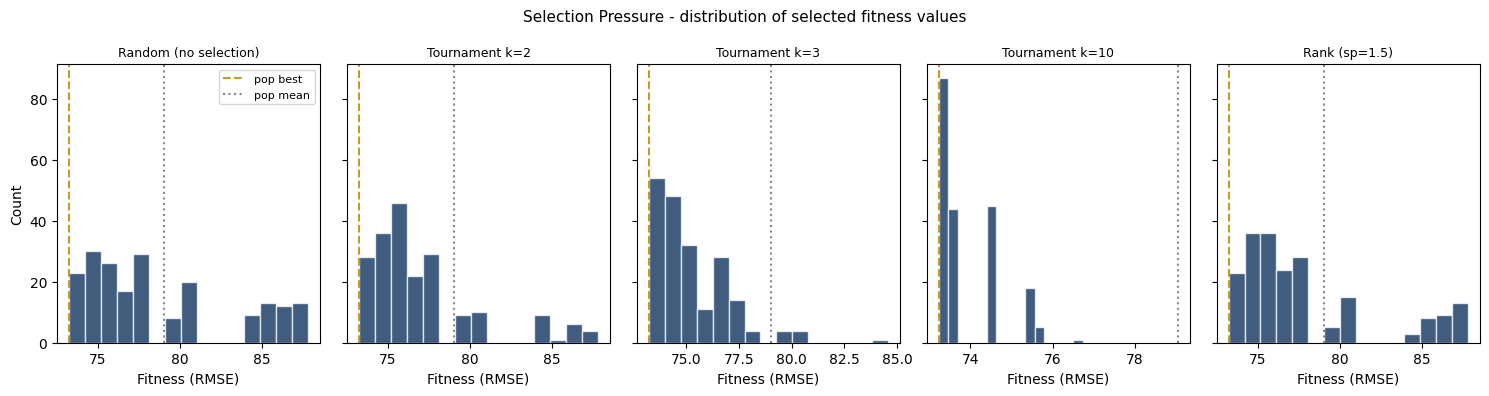

In [ ]:
sys.path.insert(0, "../src/genetic_operators")
rng = np.random.default_rng(42)
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

# create a small population
population = [Individual.random(fitness_fn, rng) for _ in range(20)]
_ = [ind.fitness for ind in population]  # trigger evaluation

fitnesses = [ind.fitness for ind in population]

# compare selection pressure across operators
operators = [
    ("Random (no selection)", None),
    ("Tournament k=2",  TournamentSelection(tournament_size=2)),
    ("Tournament k=3",  TournamentSelection(tournament_size=3)),
    ("Tournament k=10", TournamentSelection(tournament_size=10)),
    ("Rank (sp=1.5)",   RankSelection(selection_pressure=1.5)),
]

n_selections = 200
fig, axes = plt.subplots(1, len(operators), figsize=(15, 4), sharey=True)

for ax, (label, op) in zip(axes, operators):
    if op is None:
        selected_f = [population[rng.integers(0, len(population))].fitness
                      for _ in range(n_selections)]
    else:
        selected = op.select(population, n_parents=n_selections, rng=rng)
        selected_f = [ind.fitness for ind in selected]

    ax.hist(selected_f, bins=15, color="#002654", alpha=0.75, edgecolor="white")
    ax.axvline(min(fitnesses), color="#C49A28", lw=1.5, linestyle="--", label="pop best")
    ax.axvline(np.mean(fitnesses), color="#888", lw=1.5, linestyle=":", label="pop mean")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Fitness (RMSE)")
    if ax == axes[0]:
        ax.set_ylabel("Count")

axes[0].legend(fontsize=8)
plt.suptitle("Selection Pressure - distribution of selected fitness values", fontsize=11)
plt.tight_layout()
plt.show()

## 5.2. Crossover

Crossover combines the chromosomes of two parents to produce two offspring, with the goal of preserving and recombining beneficial building blocks. Because draw order is semantically meaningful in this problem (bottom-to-top rendering, occlusion), operators that preserve contiguous chromosome segments may produce more visually coherent offspring and so they must be tested.

Five strategies are implemented in `crossover.py`:

| Operator | Mechanism | Locality | Notes |
|----------|-----------|----------|-------|
| `SinglePointCrossover` | One random cut point; everything after it is exchanged between parents | High | Preserves contiguous blocks |
| `UniformCrossover`$(p)$| Per-gene swap with probability $p$ | Low | Maximum mixing, destroys locality |
| `KPointCrossover`$(k)$ | $k$ cut points; preserves smaller blocks while allowing more recombination | Medium | Generalises single-point |
| `SegmentShuffleCrossover` | Random number of cuts $k \in [k_{\min}, k_{\max}]$ cuts; each segment independently assigned to a child  | Medium | Variable granularity per call |
| `BlendCrossover` $(\alpha)$ |Interpolates parents' genes to create new triangles and extends by $\alpha$ (Eshelman & Schaffer, 1993) | Continuous | Only operator that can create parameter values not present in either parent |

<br>

> **Locality:** refers to how well a crossover operator preserves genes that are adjacent in the chromosome. High locality means neighbouring genes tend to be inherited together; low locality means each gene is inherited independently of its neighbours.

We use as baseline the **`UniformCrossover`** since it makes no assumptions about gene ordering and provides the highest mixing rate. We later  test whether locality-preserving operators (`SinglePointCrossover`, `KPointCrossover`) outperform it for this problem.

**`BlendCrossover`** (BLX-$\alpha$, Eshelman & Schaffer, 1993) is the only operator that can generate parameter values outside the range of the two parents, sampling offspring vertices and colours from $[\min - \alpha \cdot I,\ \max + \alpha \cdot I]$ where $I = \max - \min$. With $\alpha = 0$ offspring always lie between the parents; with $\alpha = 0.5$ (default) they may extend up to 50% beyond.


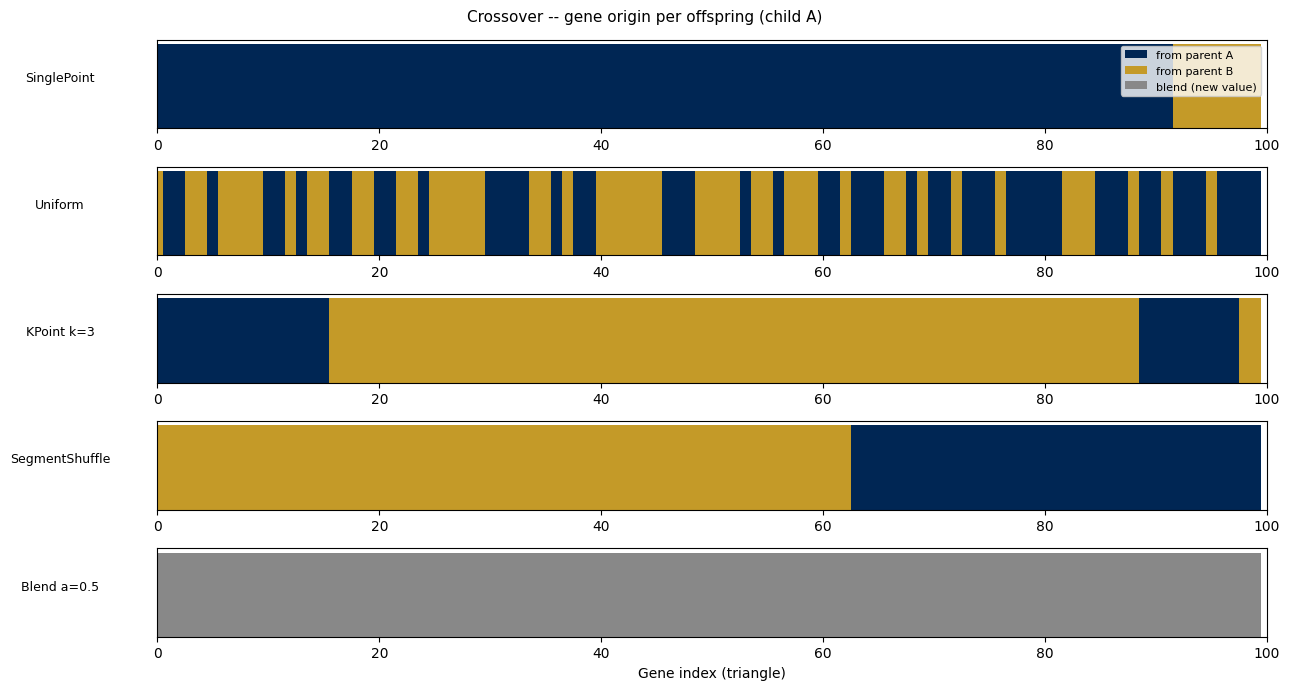

In [34]:
rng = np.random.default_rng(42)
parent_a = Individual.random(fitness_fn, rng)
parent_b = Individual.random(fitness_fn, rng)

operators = [
    ("SinglePoint",     SinglePointCrossover()),
    ("Uniform",         UniformCrossover(swap_prob=0.5)),
    ("KPoint k=3",      KPointCrossover(k=3)),
    ("SegmentShuffle",  SegmentShuffleCrossover(k_min=1, k_max=5)),
    ("Blend a=0.5",     BlendCrossover(alpha=0.5)),
]

fig, axes = plt.subplots(len(operators), 1, figsize=(13, 7))

for ax, (label, op) in zip(axes, operators):
    child_a, child_b = op.cross(parent_a, parent_b, rng)

    origin_a = []
    for i, tri in enumerate(child_a.triangles):
        if tri in parent_a.triangles:
            origin_a.append("A")
        elif tri in parent_b.triangles:
            origin_a.append("B")
        else:
            origin_a.append("?")  # blend crossover -- new value

    colors = ["#002654" if o == "A" else "#C49A28" if o == "B" else "#888"
              for o in origin_a]

    ax.bar(range(100), [1]*100, color=colors, width=1.0, edgecolor="none")
    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_ylabel(label, fontsize=9, rotation=0, labelpad=70)
    ax.set_xlabel("Gene index (triangle)" if ax == axes[-1] else "")

legend_elements = [
    Patch(facecolor="#002654", label="from parent A"),
    Patch(facecolor="#C49A28", label="from parent B"),
    Patch(facecolor="#888",    label="blend (new value)"),
]
axes[0].legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.suptitle("Crossover -- gene origin per offspring (child A)", fontsize=11)
plt.tight_layout()
plt.show()

## 5.3. Mutation

Mutation introduces variation that crossover alone cannot provide, being the primary mechanism for escaping local optima. The **mutation rate** is applied per triangle, not per individual: at `mutation_rate=0.05`, each of the 100 triangles has an independent 5% chance of being mutated, producing on average 5 modified triangles per individual per generation.

Five concrete operators are implemented in `mutation.py`:

| Operator | What it perturbs | Search character |
|----------|-----------------|-----------------|
| `GaussianMutation`$(\sigma, rate)$ | Vertices + colour with Gaussian noise $\mathcal{N}(0, \sigma^2)$ | Local refinement  |
| `CreepMutation`$(\delta, rate)$ | Vertices + colour with bounded uniform noise $\mathcal{U}(-\delta, +\delta)$ | Fine local search, no outlier jumps |
| `ResetMutation`$(rate)$ | Replaces selected triangles with entirely new random ones | Coarse exploration, diversity injection |
| `SwapMutation`$(rate, n)$ | Swaps draw-order positions of $n$ triangle pairs | Explores ordering space only |
| `CompositeMutation`$(ops)$ | Applies multiple operators in sequence | Combined fine + coarse search |

Four adaptive decay schedulers extend the operators above by annealing noise parameters over generations:

| Scheduler | Targets | Behaviour |
|-----------|---------|-----------|
| `SigmaDecayScheduler` | `GaussianMutation` | Exponential decay of both $\sigma$ values from max to min over all generations |
| `DeltaDecayScheduler` | `CreepMutation` | Identical decay logic applied to $\delta$ parameters |
| `AsymmetricSigmaDecayScheduler` | `GaussianMutation` | Decays vertex and colour $\sigma$ at independent rates - colour stabilises at 50% of generations by default, vertices decay over the full run |
| `CompositeSigmaDecayScheduler` | `GaussianMutation` inside `CompositeMutation` | Same exponential decay logic, targeting the inner Gaussian operator by reference |

**`GaussianMutation`** is the baseline operator, implementing local search: small $\sigma$ values refine an already-good solution; larger values allow bigger jumps. The `set_sigma()` method allows $\sigma$ to be updated in place each generation, enabling adaptive mutation without reconstructing the operator object.

**`CreepMutation`** is structurally similar to `GaussianMutation` but uses bounded uniform noise. Knowing that large outlier jumps are structurally impossible, this mutations makes it more conservative and better suited to late-stage refinement when triangles are already well-placed.

**`CompositeMutation`** chains operators in sequence (output of operator $i$ feeds into operator $i+1$), combining `GaussianMutation` for fine-grained local search with `ResetMutation` for coarse exploration and `SwapMutation` for draw-order optimisation - all within a single unified call to the engine.

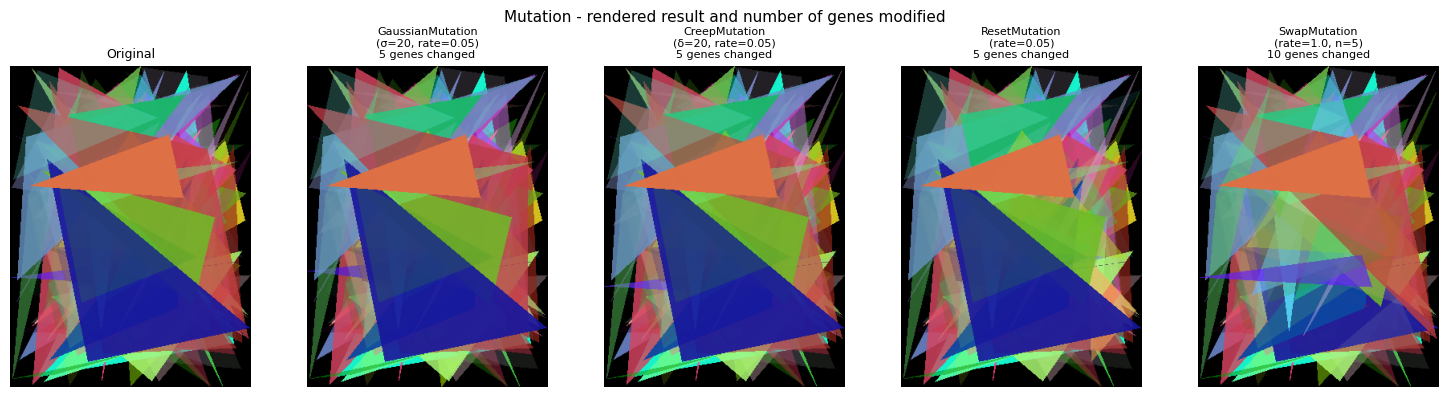

In [ ]:

rng = np.random.default_rng(0)
original = Individual.random(fitness_fn, rng)

operators = [
    ("GaussianMutation\n(σ=20, rate=0.05)", GaussianMutation(mutation_rate=0.05, vertex_sigma=20, color_sigma=20)),
    ("CreepMutation\n(δ=20, rate=0.05)",    CreepMutation(mutation_rate=0.05, vertex_delta=20, color_delta=20)),
    ("ResetMutation\n(rate=0.05)",           ResetMutation(mutation_rate=0.05)),
    ("SwapMutation\n(rate=1.0, n=5)",        SwapMutation(mutation_rate=1.0, n_swaps=5)),
]

fig, axes = plt.subplots(1, len(operators) + 1, figsize=(15, 4))

axes[0].imshow(render(original.triangles))
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for ax, (label, op) in zip(axes[1:], operators):
    mutated = op.mutate(original, np.random.default_rng(1))

    # highlight changed triangles
    changed = [i for i, (t1, t2) in enumerate(zip(original.triangles, mutated.triangles))
               if t1 != t2]

    rendered = render(mutated.triangles)
    ax.imshow(rendered)
    ax.set_title(f"{label}\n{len(changed)} genes changed", fontsize=8)
    ax.axis("off")

plt.suptitle("Mutation - rendered result and number of genes modified", fontsize=11)
plt.tight_layout()
plt.show()

# 6. Evolutionary Engine

The GA engine is implemented across two classes - `Population` (`population.py`) and `GeneticAlgorithm` (`ga.py`) - following a clear separation of concerns: `Population` manages the collection of individuals and exposes evaluation, statistics, diversity and replacement logic; `GeneticAlgorithm` orchestrates the evolutionary loop using injected operator strategies.

## 6.1. Population

`Population` is a container for a single generation of `Individual` objects, implemented in `population.py`. Following the Single Responsibility Principle, it does not implement the evolutionary loop and instead encapsulates four concerns: initialisation, evaluation, statistics and diversity tracking, and generational replacement.

**Key design choices:**

- **Lazy sorted order:** after every `evaluate()` call, individuals are sorted ascending by fitness. This makes `best` and `worst` access $O(1)$ and avoids repeated sorting in the engine.

- **Parallel evaluation:** fitness evaluation is opt-in parallel via `ThreadPoolExecutor`. PIL rendering releases the GIL (I/O-bound), making threads effective without multiprocessing overhead. Serial evaluation is the default — parallel is only beneficial for populations $\geq 50$ due to thread overhead.

- **Elitism in replacement:** `replace(offspring, n_elites)` carries the top $k$ individuals from the current generation forward unchanged before filling remaining slots with offspring. Elitism guarantees the best solution found is never lost to random variation. Even $k=1$ significantly stabilises convergence by preventing regression — but high elitism values risk reducing population diversity by repeatedly propagating the same genetic material.

- **Diversity metrics:** four metrics are exposed:

  | Metric | Type | Formula | Logged |
  |--------|------|---------|--------|
  | Phenotypic variance | Fitness spread | $V(P) = \frac{1}{m-1}\sum_{i=1}^{m}(f_i - \bar{f})^2$ | Every generation |
  | Genotypic variance | Chromosome spread | $V(P) = \frac{1}{m-1}\sum_{i=1}^{m}(d_i - \bar{d})^2$ | Every 10 generations |
  | Phenotypic entropy | Fitness distribution | $H(P) = \sum_j F_j \log F_j$ | On demand |
  | Genotypic entropy | Genotype distribution | $H(P) = \sum_j F_j \log F_j$ | On demand |

  where $d_i$ is the normalised L2 distance from individual $i$'s chromosome to the best individual's chromosome. Chromosome vectors are normalised before computing distances so that vertex coordinates (range $[0, 400]$) and colour channels (range $[0, 255]$) contribute on comparable scales.

- **Population size and diversity:** `population_size` is a primary driver of genetic diversity - larger populations maintain more parallel search threads and reduce the probability of premature convergence, at the cost of more fitness evaluations per generation. In our experiments we firstly use $N = 50$, which balances diversity against computational budget. The interaction between population size, elitism and selection pressure is studied in our final tests.

## 6.2. GA Engine

The `GeneticAlgorithm` class orchestrates the full evolutionary loop. It depends exclusively on abstract operator interfaces (`SelectionOperator`, `CrossoverOperator`, `MutationOperator`) injected at construction - a dependency injection pattern that makes the engine agnostic to which concrete operators are active.

**Generational loop:**

```
INITIALISE population (N individuals, chosen init_strategy)
EVALUATE all individuals

FOR generation g = 1 … G:
    1. Log statistics (best, mean, std, diversity)
    2. Check early stopping
    3. SELECT 2 × n_pairs parents
    4. For each pair:
         if rng < crossover_rate -> CROSSOVER -> (child_a, child_b)
         else -> copy parents unchanged
         MUTATE child_a and child_b
    5. REPLACE population (offspring + n_elites from current generation)
    6. EVALUATE new offspring
    7. Fire callback (e.g. sigma decay scheduler)

RETURN best individual found across all generations
```

**`GAConfig`: hyperparameter configuration:**

`GAConfig` centralises all hyperparameters in a dataclass with sensible defaults, primarily to allow the class to be instantiated and tested in isolation. The actual experimental values used in our study are defined in `runner.py` and overrride these defaults: 

| Parameter | Default | Description |
|-----------|---------|-------------|
| `population_size` | 50 | Individuals per generation |
| `n_generations` | 500 | Maximum generations (overridden to 3000 in runner) |
| `crossover_rate` | 0.8 | Per-pair crossover probability |
| `n_elites` | 1 | Individuals carried forward unchanged (overridden per phase in runner) |
| `n_workers` | 1 | Threads for parallel fitness evaluation |
| `seed` | `None` | Fixed per-run in the runner to 42, 43, or 44 |

**Early stopping:** two mechanisms prevent wasted compute:

- **`EarlyStopping`** - stops if best fitness does not improve by more than `tolerance` over `patience` consecutive generations.
- **`DiversityAwareEarlyStopping`** - requires fitness stagnation **and** diversity collapse before stopping. If fitness is stuck but the population is still genetically diverse, the stagnation counter resets and the algorithm is given more time to exploit remaining diversity. Diversity collapse is signalled when either phenotypic or genotypic variance falls below configurable thresholds.

**Checkpointing:** the best individual is saved every `checkpoint_interval` generations as both a JSON (for reloading) and a PNG (for visual inspection), protecting against data loss during long runs.

**Callback system:** `run()` accepts an optional callback fired at the end of every generation with signature `callback(generation, best, stats)`. This is how the sigma/delta decay schedulers integrate with the engine - passed as callbacks, they update operator parameters in place each generation without the engine needing to know about them.

In [ ]:
sys.path.insert(0, "../src")


rng_demo = np.random.default_rng(42)
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

# Assemble the GA with baseline operators 
ga = GeneticAlgorithm(
    fitness_fn = fitness_fn,
    selection  = TournamentSelection(tournament_size=3),
    crossover  = UniformCrossover(),
    mutation   = GaussianMutation(mutation_rate=0.05, vertex_sigma=15, color_sigma=15),
    config     = GAConfig(
        population_size = 10,        # small for demonstration purposes
        n_generations   = 20,
        n_elites        = 1,
        crossover_rate  = 0.8,
        early_stopping  = EarlyStopping(patience=10),
        seed            = 42,
    )
)

best = ga.run(init_strategy="random")

print(f"Best RMSE after {len(ga.generation_log)-1} generations: {best.fitness:.4f}")
print(f"Log entries: {len(ga.generation_log)}")
print(f"\nFirst 3 generations:")
for entry in ga.generation_log[:3]:
    print(f"  gen {entry['generation']:>3} | best={entry['best']:.4f} | "
          f"mean={entry['mean']:.4f} | diversity={entry['diversity']:.6f}")

Best RMSE after 20 generations: 65.7129
Log entries: 21

First 3 generations:
  gen   0 | best=73.2346 | mean=78.3369 | diversity=17.205687
  gen   1 | best=73.0195 | mean=74.8053 | diversity=2.377726
  gen   2 | best=72.1022 | mean=73.5086 | diversity=0.925396


# 7. Experimental Pipeline

The experimental pipeline is orchestrated by `runner.py`, which translates high-level experiment descriptions into reproducible GA runs and structured outputs. Each configuration is defined as a `RunConfig` dataclass - a declarative record of operator choices, hyperparameters, and metadata - and executed across multiple seeds via `execute_single_run()`.

Run `python runner.py --target data/girl_pearl.png` to execute the full experiment.

## 7.1. Output Structure

Every run produces a structured directory tree under `runner_outputs/`:

```
runner_outputs/
├── results.csv                       <- global results table, one row per (config, seed) run
└── <config_name>/
    ├── config_results.csv            <- same columns as results.csv, filtered to this config
    └── seed_42/
        ├── config.json               <- full RunConfig (operators, hyperparams, seed)
        ├── ga_config.json            <- GAConfig dataclass serialised to JSON
        ├── generation_log.json       <- per-generation stats (see below)
        ├── best_final.png            <- rendered best individual at end of run
        ├── best_final_triangles.json <- chromosome of best individual (reloadable)
        └── checkpoints/
            ├── gen_0000.png
            ├── gen_0000_metrics.json
            ├── gen_0100.png
            ├── gen_0100_metrics.json
            └── ...
```

**`generation_log.json`** contains one entry per generation with the following fields:

| Field | Description |
|-------|-------------|
| `generation` | Generation index |
| `elapsed_s` | Wall-clock time since run start |
| `best` | Best RMSE in the population |
| `mean` | Mean RMSE across all individuals |
| `std` | Standard deviation of RMSE |
| `worst` | Worst RMSE in the population |
| `diversity` | Phenotypic variance (primary diversity signal) |

Checkpoint metrics JSONs (`gen_XXXX_metrics.json`) are saved every 100 generations and extend the generation log with the full diversity report.

This separation allows lightweight per-generation logging (fitness only) without the overhead of computing the full chromosome matrix every generation, while still preserving the complete diversity profile at regular intervals for post-hoc analysis.

**`results.csv`** is the primary analysis table: one row per (config, seed) run, containing the final best fitness, number of generations actually run, elapsed time and all operator/hyperparameter choices. At the end of the full experiment, this file aggregates all runs across all phases.

## 7.2. Phase Structure

The first five phases follow a **One Factor At a Time (OFAT)** protocol: each phase varies a single component while holding all others fixed at the best value found so far. This isolates each operator's contribution to final fitness.

We recognise the limitations of OFAT: testing elitism before finding the best selection method may lead to suboptimal elite counts, and some cross-phase combinations may outperform the best of each phase in isolation. Phases 8–11 address this with targeted interaction checks and a grid search.

| Phase | What varies | Fixed at |
|-------|-------------|----------|
| 1 | (baseline) | Tournament k=3, Uniform XO, Gaussian fixed, 5 elites |
| 2 | `n_elites` $ \in {0, 1, 3, 5, 7}$ | Baseline operators |
| 3 | Selection operator | Best elites from Phase 2 |
| 4 | Crossover operator | Best from previous phases |
| 5 | Mutation operator | Best from previous phases|

- **Phase 1 -Baseline**

The baseline configuration was chosen to represent the most common neutral choices in the GA literature:

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Selection | `TournamentSelection(k=3)` | Default; moderate pressure, robust |
| Crossover | `UniformCrossover` | No assumptions about gene ordering |
| Mutation | `GaussianMutation` (fixed $\sigma$) | Natural choice for continuous parameter spaces |
| Elites | 5 | Preserves top solutions without dominating offspring pool |

- **Phase 2 - Elitism sweep:** tests $k \in \{0, 1, 3, 5, 7\}$ to quantify the effect of elitism on convergence speed and final fitness.

- **Phase 3 - Selection sweep:** tests `TournamentSelection` with $k \in \{2, 5, 10\}$ and `RankSelection`, holding all else at baseline.

- **Phase 4 - Crossover sweep:** tests all five crossover operators. Notably, the best selection from Phase 3 is carried forward 

- **Phase 5 - Mutation sweep:** tests the mutation configurations seen before.

Each configuration is run with **3 seeds (42, 43, 44)**. Because GAs are stochastic, a single run may reflect a lucky initialisation rather than the true performance of a configuration. Three runs allow us to report mean $\pm$ std and detect gross outliers.

We acknowledge that 3 runs provides limited statistical power. Running 30 or more replicates would be the gold standard, but it was not feasible given the computational constraints of this project.

## 7.3. Extended Phases 

Following the OFAT study, six additional phases test combinations and hyperparameter interactions that OFAT cannot capture:

| Phase | Description |
|-------|-------------|
| 6 | Best configuration with 20 000 generations (convergence ceiling) |
| 7 | Initialisation strategy sweep (6 strategies, best operators) |
| 8 | Elitism re-test with best operators from Phases 3–5 |
| 9 | Interaction check: `TournamentSelection` ($k=5$) with best mutations |
| 10 | Grid search over `mutation_rate` $\times$ `vertex_sigma_max` |
| 11 | Population size sweep ($N \in \{100, 150\}$) with best configuration |
| 12 | Best configuration with $N \in \{150, 300\}$ and 20 000 generations |

# 8. Results

This section presents the quantitative results across all phases. For each phase, we compare configurations by final RMSE (mean ± std across 3 seeds) and assess statistical significance using the Mann-Whitney U test ($\alpha = 0.05$).

In [ ]:
sys.path.insert(0, "../src")
sys.path.insert(0, "..")

OUTPUT_ROOT = "../runner_outputs"
RESULTS_CSV = os.path.join(OUTPUT_ROOT, "results.csv")

# load results
def load_results(path=RESULTS_CSV):
    if not os.path.exists(path):
        print("results.csv not found — run the runner first.")
        return []
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def group_by_config(rows):
    grouped = defaultdict(list)
    for r in rows:
        grouped[(int(r["phase"]), r["run_name"])].append(float(r["final_best_fitness"]))
    return grouped

rows = load_results()
grouped = group_by_config(rows)

print(f"Loaded {len(rows)} runs across {len(grouped)} configurations.")

Loaded 100 runs across 48 configurations.


## 8.1. Phase-by-Phase Convergence Curves

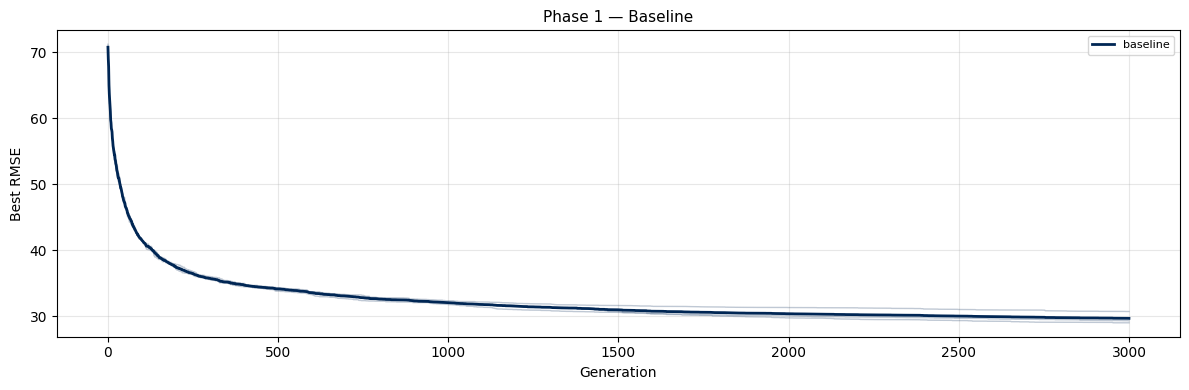

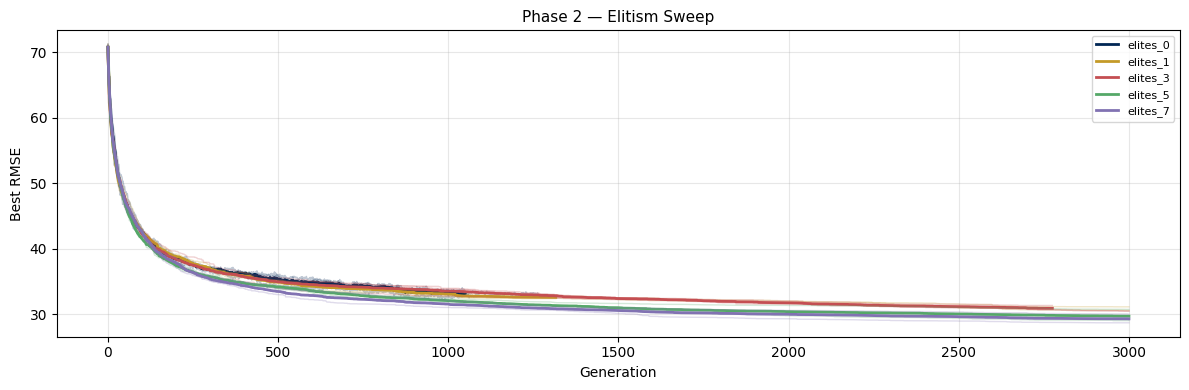

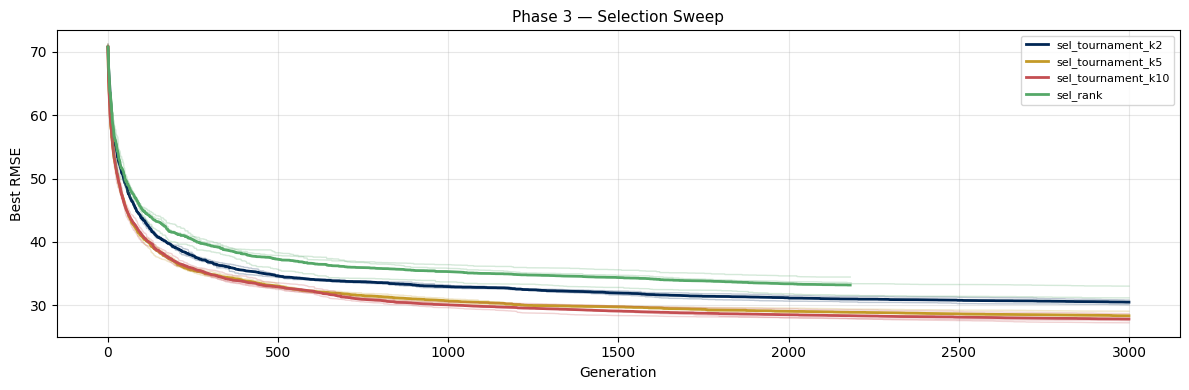

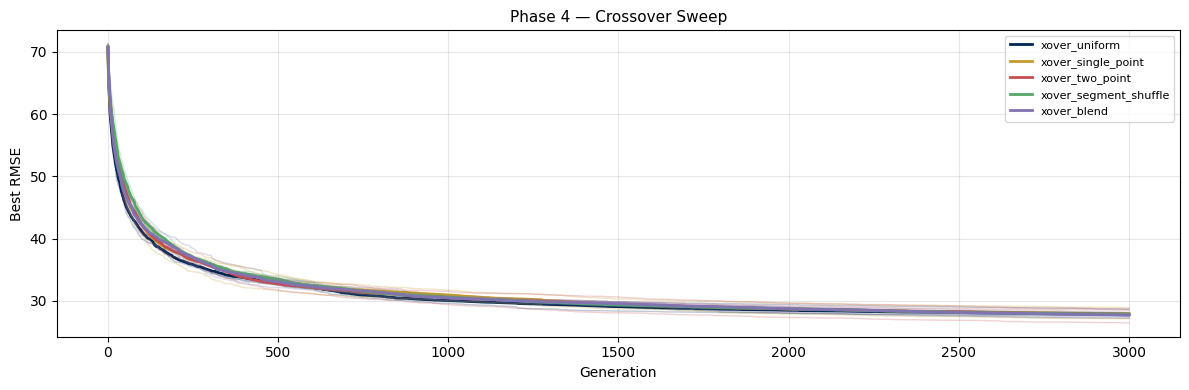

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_28535/2433656624.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc="upper right")


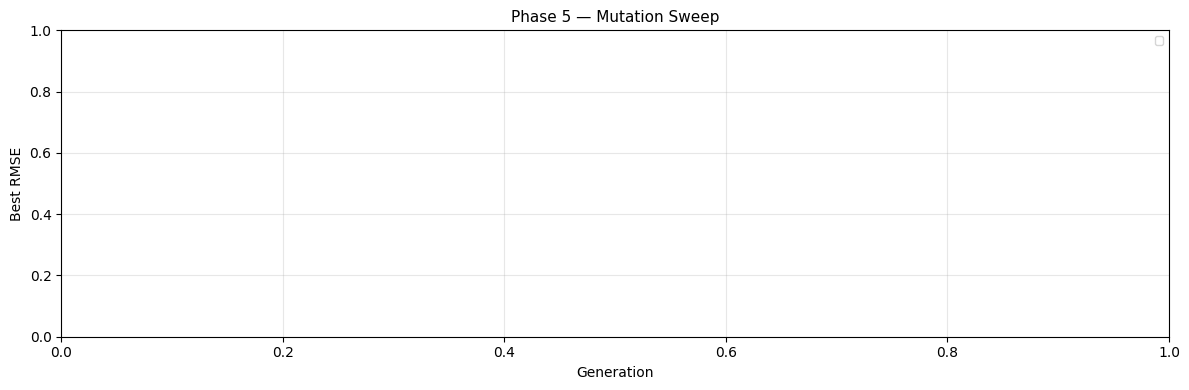

In [26]:
# convergence curves per phase
def load_generation_log(config_name, seed):
    path = os.path.join(OUTPUT_ROOT, config_name, f"seed_{seed}", "generation_log.json")
    if not os.path.exists(path):
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)

SEEDS = [42, 43, 44]
COLORS = ["#002654", "#C49A28", "#C44E52", "#55A868", "#8172B2", "#64B5CD"]

def plot_phase_convergence(phase, title):
    configs_in_phase = [(name, fits) for (ph, name), fits in grouped.items() if ph == phase]
    if not configs_in_phase:
        print(f"No results yet for Phase {phase}")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    for i, (config_name, _) in enumerate(configs_in_phase):
        color = COLORS[i % len(COLORS)]
        all_curves = []
        for seed in SEEDS:
            log = load_generation_log(config_name, seed)
            if log:
                curve = [entry["best"] for entry in log]
                ax.plot(curve, color=color, alpha=0.25, lw=1)
                all_curves.append(curve)
        if all_curves:
            min_len = min(len(c) for c in all_curves)
            mean_curve = np.mean([c[:min_len] for c in all_curves], axis=0)
            ax.plot(mean_curve, color=color, lw=2,
                    label=config_name.split("_", 1)[1] if "_" in config_name else config_name)

    ax.set_xlabel("Generation")
    ax.set_ylabel("Best RMSE")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_phase_convergence(1, "Phase 1 — Baseline")
plot_phase_convergence(2, "Phase 2 — Elitism Sweep")
plot_phase_convergence(3, "Phase 3 — Selection Sweep")
plot_phase_convergence(4, "Phase 4 — Crossover Sweep")
plot_phase_convergence(5, "Phase 5 — Mutation Sweep")

### 8.2 Final Fitness Comparison per Phase

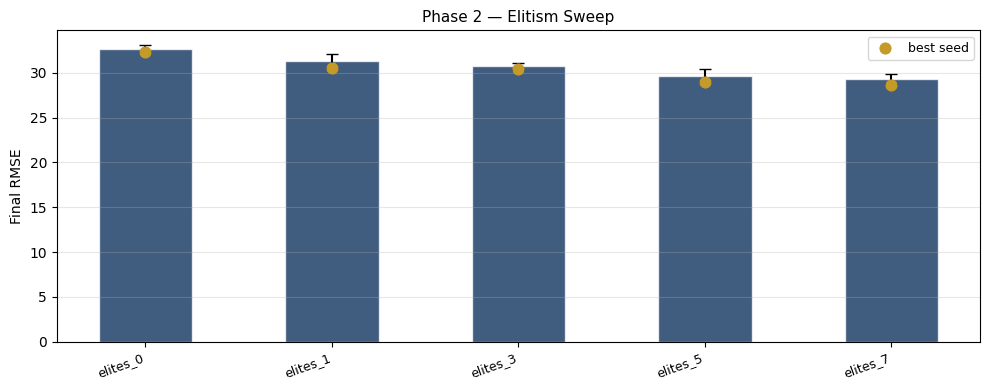


Config                                  Mean      Std     Best

p2_elites_0                          32.7169   0.3806  32.3198
p2_elites_1                          31.3522   0.7557  30.5660
p2_elites_3                          30.7541   0.4061  30.4577
p2_elites_5                          29.6871   0.7462  29.0168
p2_elites_7                          29.2862   0.5409  28.6825


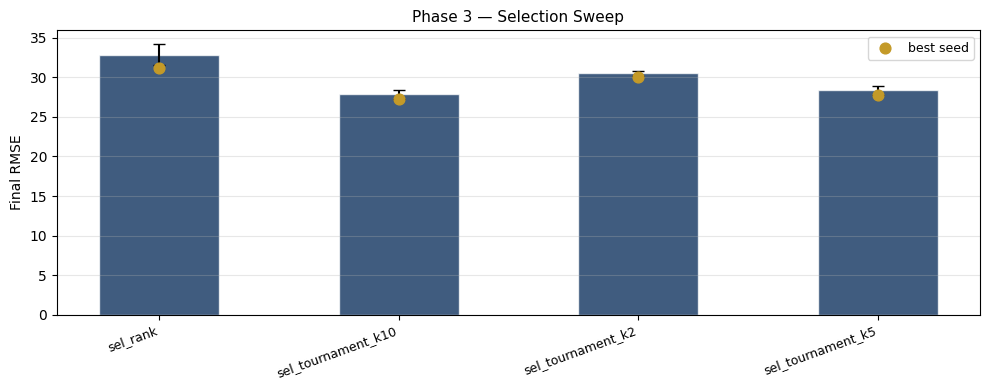


Config                                  Mean      Std     Best

p3_sel_rank                          32.8919   1.3466  31.1781
p3_sel_tournament_k10                27.8382   0.6196  27.2415
p3_sel_tournament_k2                 30.4997   0.3042  30.0978
p3_sel_tournament_k5                 28.3515   0.5353  27.7683


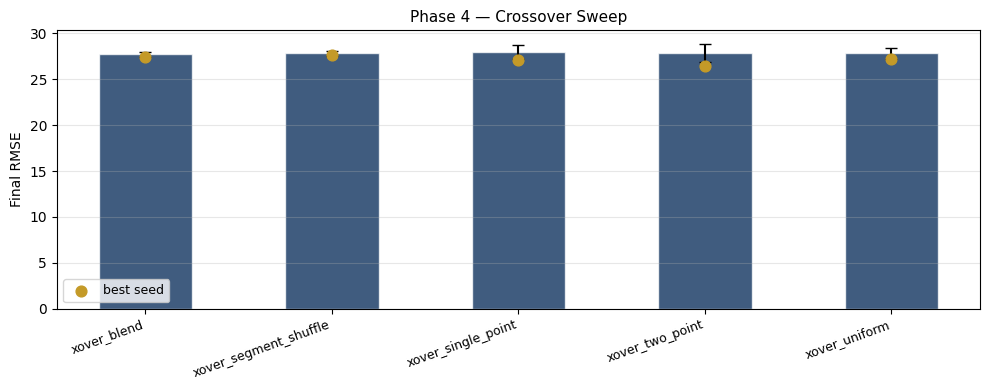


Config                                  Mean      Std     Best

p4_xover_blend                       27.7295   0.3045  27.4089
p4_xover_segment_shuffle             27.8241   0.2491  27.6224
p4_xover_single_point                27.9724   0.7390  27.1470
p4_xover_two_point                   27.9040   0.9957  26.4993
p4_xover_uniform                     27.8382   0.6196  27.2415


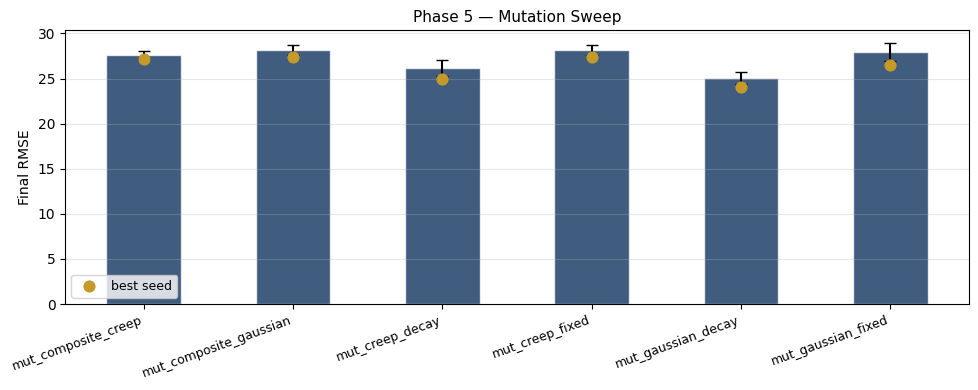


Config                                  Mean      Std     Best

p5_mut_composite_creep               27.6440   0.4537  27.1341
p5_mut_composite_gaussian            28.1903   0.5386  27.4333
p5_mut_creep_decay                   26.1783   0.8889  24.9325
p5_mut_creep_fixed                   28.1863   0.5727  27.4068
p5_mut_gaussian_decay                25.0458   0.7030  24.0818
p5_mut_gaussian_fixed                27.9040   0.9957  26.4993


In [27]:
# bar chart: mean ± std per config per phase
def plot_phase_summary(phase, title):
    configs = [(name, fits) for (ph, name), fits in sorted(grouped.items()) if ph == phase]
    if not configs:
        print(f"No results yet for Phase {phase}")
        return

    names  = [n.split("_", 1)[1] if "_" in n else n for n, _ in configs]
    means  = [np.mean(f) for _, f in configs]
    stds   = [np.std(f)  for _, f in configs]
    bests  = [np.min(f)  for _, f in configs]

    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(x, means, yerr=stds, capsize=4,
                  color="#002654", alpha=0.75, edgecolor="white", width=0.5)
    ax.scatter(x, bests, color="#C49A28", zorder=5, s=60, label="best seed")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Final RMSE")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # print table
    print(f"\n{'Config':<35} {'Mean':>8} {'Std':>8} {'Best':>8}")
    print("" * 62)
    for (name, fits), mean, std, best in zip(configs, means, stds, bests):
        print(f"{name:<35} {mean:>8.4f} {std:>8.4f} {best:>8.4f}")

for phase, title in [
    (2, "Phase 2 — Elitism Sweep"),
    (3, "Phase 3 — Selection Sweep"),
    (4, "Phase 4 — Crossover Sweep"),
    (5, "Phase 5 — Mutation Sweep"),
]:
    plot_phase_summary(phase, title)

In [ ]:
output_root = "../runner_outputs"

if not os.path.exists(output_root):
    print("No outputs yet — run the runner first.")
else:
    results_csv = os.path.join(output_root, "results.csv")
    if not os.path.exists(results_csv):
        print("results.csv not found — no completed runs yet.")
    else:
        # read csv manually
        with open(results_csv, newline="", encoding="utf-8") as f:
            rows = list(csv.DictReader(f))

        phases   = sorted(set(r["phase"] for r in rows))
        configs  = set(r["run_name"] for r in rows)

        print(f"Total runs logged : {len(rows)}")
        print(f"Phases covered    : {phases}")
        print(f"Configs covered   : {len(configs)}")
        print()

        # group by phase + config
        grouped = defaultdict(list)
        for r in rows:
            grouped[(r["phase"], r["run_name"])].append(float(r["final_best_fitness"]))

        print(f"{'Phase':<7} {'Config':<40} {'Mean RMSE':>10} {'Std':>8} {'Best RMSE':>10} {'Runs':>5}")
        print("" * 82)

        current_phase = None
        for (phase, name), fitnesses in sorted(grouped.items()):
            if phase != current_phase:
                current_phase = phase
                print(f"\n Phase {phase}")
            mean = sum(fitnesses) / len(fitnesses)
            std  = (sum((x - mean)**2 for x in fitnesses) / len(fitnesses)) ** 0.5
            best = min(fitnesses)
            print(f"{phase:<7} {name:<40} {mean:>10.4f} {std:>8.4f} {best:>10.4f} {len(fitnesses):>5}")

Total runs logged : 100
Phases covered    : ['1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9']
Configs covered   : 48

Phase   Config                                    Mean RMSE      Std  Best RMSE  Runs


 Phase 1
1       p1_baseline                                 29.6871   0.7462    29.0168     3

 Phase 10
10      p10_rate_001_sigmax_15                      25.2382   0.0000    25.2382     1
10      p10_rate_001_sigmax_40                      23.6363   0.0000    23.6363     1
10      p10_rate_001_sigmax_80                      22.9914   0.0000    22.9914     1
10      p10_rate_005_sigmax_15                      25.6437   0.0000    25.6437     1
10      p10_rate_005_sigmax_80                      25.7784   0.0000    25.7784     1
10      p10_rate_01_sigmax_15                       27.8613   0.0000    27.8613     1
10      p10_rate_01_sigmax_40                       27.2147   0.0000    27.2147     1
10      p10_rate_01_sigmax_80                       28.3089   0.0000    28.308

### 8.4 Diversity Analysis

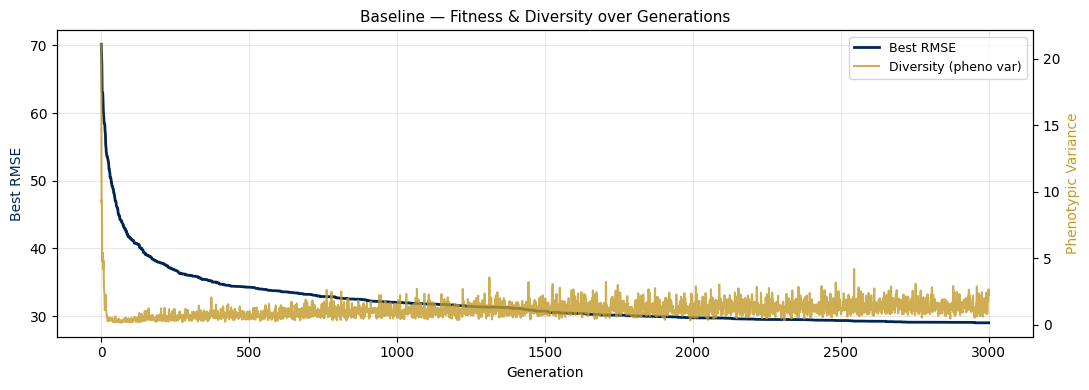

In [29]:
# diversity over generations for best config
def plot_diversity(config_name, seed=42, title=None):
    log = load_generation_log(config_name, seed)
    if not log:
        print(f"No log found for {config_name} seed {seed}")
        return

    gens      = [e["generation"] for e in log]
    diversity = [e["diversity"]  for e in log]
    best_fit  = [e["best"]       for e in log]

    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax2 = ax1.twinx()

    ax1.plot(gens, best_fit,  color="#002654", lw=2, label="Best RMSE")
    ax2.plot(gens, diversity, color="#C49A28", lw=1.5, alpha=0.8, label="Diversity (pheno var)")

    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Best RMSE", color="#002654")
    ax2.set_ylabel("Phenotypic Variance", color="#C49A28")
    ax1.set_title(title or config_name, fontsize=11)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# replace with your best config name after analysis
plot_diversity("p1_baseline", seed=42, title="Baseline — Fitness & Diversity over Generations")

## 8.5. Statistical Validation

### 8.5.1. Motivation

Genetic Algorithms are stochastic optimisation methods. This means that a single run, no matter how good, is not sufficient evidence that one configuration is genuinely better than another. 

To rigorously validate the improvements achieved through the optimisation process, we apply formal statistical hypothesis testing. The goal is to answer the following question: **is the performance difference between our best model and the baseline statistically significant, or could it be explained by random variation?**

This type of analysis is standard practice in Evolutionary Computation research and follows the methodology described in Vanneschi & Silva (2025), which recommends running multiple independent experiments and comparing distributions of results rather than individual outcomes.

### 8.5.2. Experimental Setup

The statistical comparison was conducted between two configurations:

| | **Best Model** (p12_final) | **Baseline** (p1_baseline) |
|---|---|---|
| Selection | Tournament $(k=10)$ | Tournament $(k=3)$ |
| Crossover | Blend $(\alpha=0.5)$ | Uniform $(swap=0.5)$ |
| Mutation | Gaussian Decay $(\sigma: 80->2)$| Gaussian Fixed $(\sigma=15)$ |
| Elitism | 3 elites | 5 elites |
| Init strategy | Quadrant | Random |

Both configurations were run under identical computational conditions:
- **30 independent runs** per configuration (seeds 0-29)
- **Population size:** 50 individuals
- **Generations:** 1000 per run
- **Fitness function:** RMSE

> **Note**: both the number of generations (reduced from 20 000 to 1000) and the population size (reduced from 150 to 50) were adjusted from the final production run for computational feasibility. The relative performance ordering between configurations is consistent across different parameter settings, as confirmed by the phase sweep results in the previous sections.

The full implementation is available in `statistical_analysis.py`.

### 8.5.3. Statistical Pipeline

Before choosing a test, we verified whether the 30 RMSE values from each configuration followed a normal distribution, using the **Shapiro-Wilk test**. We use this test rather than Kolmogorov-Smirnov test as it is more indicated for small samples ass this one (n=30).  The hypothesis of this test are:

- **$H_0$:** the data follows a normal distribution.
- **$H_1$:** the data does not follow a normal distribution.

A p-value above $ \alpha = 0.05$ means we fail to reject $H_0$, meaning that we have no evidence against normality and can treat the sample as normally distributed.

| | Shapiro-Wilk p-value | Normal? |
|---|---|---|
| Best Model | 0.6819 |  Yes |
| Baseline | 0.8443 |  Yes |

Since both samples are normally distributed, we applied the **Welch t-test**, a variant of Student's t-test that does not assume equal variances between groups. This is the appropriate parametric test for this scenario.

The Welch t-test operates under the following hypotheses:

- **$H_0$:** the two configurations have the same mean RMSE i.e., any observed difference is due to random variation.
- **$H_1$:** the two configurations have different mean RMSE i.e., the difference is systematic and not due to chance.

The test computes a t-statistic based on the difference between the two sample means, scaled by their standard errors. If the resulting p-value falls below the significance threshold $ \alpha = 0.05$ , we reject $H_0$ and conclude that the difference is statistically significant.

### 8.5.4. Results

- **Descriptive Statistics**

| | **Best Model** | **Baseline** |
|---|---|---|
| Mean RMSE | 26.8823 | 32.3077 |
| Std RMSE | 0.5125 | 0.9498 |
| Median RMSE | 26.8946 | 32.2949 |
| n runs | 30 | 30 |

The best model achieves a mean RMSE of **26.88**, compared to **32.31** for the baseline, representing a reduction of approximately 16.8%. Furthermore, the best model is considerably more consistent, with a standard deviation roughly half that of the baseline, indicating more reliable convergence across independent runs.

- **Hypothesis Testing**

| Test | Statistic | p-value | Significant? | Effect size |
|---|---|---|---|---|
| Welch t-test | t = −27.53 | p < 0.001 |  Yes (***) | Cohen's d = 7.11 |

The Welch t-test confirms that the difference is **highly statistically
significant** ($p \approx 0$), well below the $ \alpha = 0.05$ threshold). The effect size of Cohen's d = 7.11 is extraordinarily large (values above 0.8 are already considered "large" in the literature). This means the two distributions are almost entirely non-overlapping, as clearly visible in the boxplot below.

In [ ]:


# Load data from JSON
with open("../src/stat_analysis_outputs/comparison_raw_rmse.json", "r") as f:
    data_raw = json.load(f)

best_model = data_raw["best_model"]
baseline   = data_raw["baseline"]

# Statistical test
_, p_best     = stats.shapiro(best_model)
_, p_baseline = stats.shapiro(baseline)
_, p_value    = stats.ttest_ind(best_model, baseline, equal_var=False)
n1, n2        = len(best_model), len(baseline)
u_stat, _     = stats.mannwhitneyu(best_model, baseline, alternative="two-sided")
cohens_d      = (np.mean(baseline) - np.mean(best_model)) / \
                np.sqrt((np.std(best_model, ddof=1)**2 + np.std(baseline, ddof=1)**2) / 2)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#f8f8f8")
ax.set_facecolor("#f8f8f8")

data   = [best_model, baseline]
labels = ["Best Model\n(p12_final)", "Baseline\n(p1_baseline)"]
colors = ["#234c7d", "#C49A28"]

bp = ax.boxplot(
    data, tick_labels=labels, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=5, alpha=0.5),
    widths=0.45,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# significance bracket
ymax    = max(max(data[0]), max(data[1]))
ymin    = min(min(data[0]), min(data[1]))
y_range = ymax - ymin
y_bar   = ymax + y_range * 0.07
y_text  = y_bar + y_range * 0.03

ax.plot([1, 1, 2, 2], [y_bar - y_range*0.01, y_bar, y_bar, y_bar - y_range*0.01],
        lw=1.5, color="black")
ax.text(1.5, y_text, "***", ha="center", va="bottom",
        fontsize=15, color="#c62828", fontweight="bold")

ax.set_ylim(ymin - y_range * 0.05, y_text + y_range * 0.1)
ax.set_ylabel("Final Best RMSE", fontsize=12)
ax.set_title(
    "Best Model vs Baseline\n"
    f"Welch t-test  p={p_value:.4e}  Cohen's d={cohens_d:.3f}\n"
    f"(pop=50, gens=1000, n={n1} runs each"
    f" | * p<0.05  ** p<0.01  *** p<0.001  ns = not significant)",
    fontsize=10, pad=12,
)
ax.grid(axis="y", linestyle="--", alpha=0.5)

best_patch = mpatches.Patch(color="#234c7d",  alpha=0.75, label="Best model (p12_final)")
base_patch = mpatches.Patch(color="#C49A28", alpha=0.75, label="Baseline (p1_baseline)")
ax.legend(handles=[best_patch, base_patch], loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../src/stat_analysis_outputs/comparison_raw_rmse.json'

> The bracket and \*\*\* annotation indicate a statistically significant difference at p < 0.001 (Welch t-test).

The statistical analysis provides strong evidence that the optimisation process led to a genuine and substantial improvement over the baseline. The best model is not only better on average, but also significantly more consistent across independent runs. The result is statistically significant at p < 0.001 with a very large effect size (Cohen's d = 7.11), confirming that the observed performance gain cannot be attributed to random variation.

## **<span style="color:#002654">10. Final Results</span>**

### 10.1 Best Reconstruction — Side by Side

In [ ]:
# best reconstruction side by side
if os.path.exists(triangles_path):
    fig, axes = plt.subplots(1, 2, figsize=(9, 6))
    axes[0].imshow(target)
    axes[0].set_title("Original\nVermeer — Girl with a Pearl Earring", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(rendered)
    axes[1].set_title(
        f"GA Reconstruction\n100 semi-transparent triangles | RMSE = {rmse:.2f}",
        fontsize=10
    )
    axes[1].axis("off")

    plt.suptitle("Final Result", fontsize=13)
    plt.tight_layout()
    plt.show()

NameError: name 'triangles_path' is not defined

### 10.2 Convergence of Best Run

In [ ]:
# convergence curve of best run
log = load_generation_log(BEST_CONFIG, BEST_SEED)
if log:
    gens     = [e["generation"] for e in log]
    best_fit = [e["best"]       for e in log]
    mean_fit = [e["mean"]       for e in log]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(gens, best_fit, color="#002654", lw=2, label="Best RMSE")
    ax.plot(gens, mean_fit, color="#C49A28", lw=1.5, alpha=0.7,
            linestyle="--", label="Mean RMSE")
    ax.fill_between(gens, best_fit, mean_fit, alpha=0.08, color="#002654")
    ax.set_xlabel("Generation")
    ax.set_ylabel("RMSE")
    ax.set_title(f"Convergence — {BEST_CONFIG} seed {BEST_SEED}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 10.3 Generalisation — Applying the Best Configuration to a New Image

To assess whether the pipeline generalises beyond the target painting, we apply the best configuration found to a visually distinct image — one with different colour distribution, spatial structure, and subject matter.

In [ ]:
# generalisation to a new image
# replace with path to your second image
NEW_IMAGE_PATH = "../data/other_image.png"

if not os.path.exists(NEW_IMAGE_PATH):
    print(f"Place a second target image at {NEW_IMAGE_PATH} to run this cell.")
else:
    new_target = np.array(Image.open(NEW_IMAGE_PATH).convert("RGB"))
    new_fitness_fn = RMSEFitness(new_target)

    mut_op = GaussianMutation(mutation_rate=0.05, vertex_sigma=40, color_sigma=40)
    scheduler = SigmaDecayScheduler(mut_op, n_generations=3000)

    ga_new = GeneticAlgorithm(
        fitness_fn = new_fitness_fn,
        selection  = TournamentSelection(tournament_size=10),  # <- update to best
        crossover  = BlendCrossover(alpha=0.5),                # <- update to best
        mutation   = mut_op,
        config     = GAConfig(
            population_size=50,
            n_generations=3000,
            n_elites=5,
            crossover_rate=0.8,
            early_stopping=EarlyStopping(patience=100),
            seed=42,
        )
    )

    best_new = ga_new.run(init_strategy="random", callback=scheduler)
    rendered_new = render(best_new.triangles)

    fig, axes = plt.subplots(1, 2, figsize=(9, 5))
    axes[0].imshow(new_target);    axes[0].set_title("New Target"); axes[0].axis("off")
    axes[1].imshow(rendered_new);  axes[1].set_title(
        f"GA Reconstruction\nRMSE = {best_new.fitness:.2f}"
    ); axes[1].axis("off")
    plt.suptitle("Generalisation — best configuration on a new image", fontsize=11)
    plt.tight_layout()
    plt.show()

## **<span style="color:#002654">11. Conclusions</span>**

> *To be completed after results analysis.*

This section will summarise:

- Which operator choices had the most impact on final RMSE
- The trade-off between exploration and exploitation observed across phases
- Whether RMSE-optimised solutions generalise to other quality metrics
- Limitations of the approach and directions for future work

**Key findings (placeholder):**

| Finding | Evidence |
|---------|----------|
| Most impactful operator | Phase X results |
| Optimal selection pressure | Phase 3 |
| Effect of sigma decay | Phase 5 |
| Generalisation quality | Section 10.3 |

---
## 10. Design Principles & Engineering Decisions

### 10.1 Immutability Throughout
`Triangle` is a frozen dataclass. `Individual` stores triangles as a tuple. All genetic operators return **new objects** — never modify in-place. This eliminates an entire class of subtle bugs (shared-state mutation mid-generation) and makes the code straightforward to reason about.

### 10.2 Dependency Injection for Operators
The GA engine (`GeneticAlgorithm`) depends only on **abstract interfaces** (`SelectionOperator`, `CrossoverOperator`, `MutationOperator`). Concrete operators are injected at construction. This makes the ablation study trivial — swapping operators doesn't touch the engine.

### 10.3 Lazy Fitness Caching
Fitness evaluation is expensive (PIL render + NumPy RMSE). Each `Individual` caches its fitness on first access. The GA engine accesses `individual.fitness` freely throughout selection, sorting, and logging without redundant re-computation.

### 10.4 Reproducibility via Seeded RNG
All randomness flows through a single `np.random.Generator` created from an explicit seed. This guarantees that any run can be reproduced exactly by passing the same seed.

### 10.5 Modular Output Structure
The runner saves structured JSON logs per generation and per seed. This separates *data collection* from *analysis* — the notebook can be re-run on saved logs without re-running the GA.

### 10.6 Draw Order as a Design Choice
The 100-triangle chromosome has **meaningful gene ordering** (draw order = rendering layer). This is an explicit design choice: crossover operators that preserve contiguous segments (single-point, two-point) may exploit this structure, while uniform crossover ignores it. The ablation study will quantify whether order-aware crossover helps.

---

## Summary

| | |
|---|---|
| **Problem** | Approximate a painting with 100 semi-transparent triangles |
| **Encoding** | 100 × (3 vertices + RGBA colour) = 700 continuous parameters |
| **Fitness** | RMSE (pixel-level error) — minimise |
| **Baseline** | Tournament k=3 / Uniform XO / Gaussian mutation / 5 elites |
| **Ablation** | 4 sweeps (elitism, selection, crossover, mutation) × 3 seeds |
| **Statistics** | Mann-Whitney U test, α = 0.05 |

---
*This notebook was auto-generated from the project source files.*  
*Run `python runner.py --target data/girl_pearl.png` to execute the full experiment.*


---

---
## 12. Color Palette Evolution

As the GA converges, the triangles' colors should progressively align with the target image's dominant palette. This section extracts the **top-K dominant colors** from the rendered checkpoint images at selected generations and compares them against the dominant colors of the original painting.

Colors are extracted via K-Means clustering in RGB space. Each swatch row represents one checkpoint; the rightmost column always shows the target palette for reference. A converging GA should produce palettes that grow visually closer to the target row as generations increase.

In [1]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.gridspec as _gs

# ---------------------------------------------------------------------------
# config
# ---------------------------------------------------------------------------
N_COLORS    = 8      # dominant colors per image
SAMPLE_FRAC = 0.25   # pixel subsample fraction for k-means speed
STEP_PAL    = 1000   # generation step for palette (independent of heatmap STEP)

# ---------------------------------------------------------------------------
# generation list -- reuse selected_gens if available, else rebuild
# ---------------------------------------------------------------------------
try:
    palette_gens = selected_gens
except NameError:
    _GEN_RE = re.compile(r"(?:gen(?:eration)?[_\-])(\d+)", re.IGNORECASE)
    def _pg(f): m = _GEN_RE.search(f); return int(m.group(1)) if m else None
    _fs = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.lower().endswith(".png") and _pg(f)],
                 key=_pg)
    gen_to_file = {_pg(f): f for f in _fs}
    all_gens    = sorted(gen_to_file)
    max_gen     = all_gens[-1]
    _tg = list(range(STEP_PAL, max_gen, STEP_PAL)) + [max_gen]
    _seen, palette_gens = set(), []
    for g in [min(all_gens, key=lambda x: abs(x - t)) for t in _tg]:
        if g not in _seen: palette_gens.append(g); _seen.add(g)

# ---------------------------------------------------------------------------
# dominant color extraction
# ---------------------------------------------------------------------------
def dominant_colors(img_arr: np.ndarray, n: int = N_COLORS) -> np.ndarray:
    """Return (n, 3) uint8 array of dominant RGB colors, sorted by prevalence."""
    pixels   = img_arr.reshape(-1, 3).astype(np.float32)
    n_sample = max(n * 100, int(len(pixels) * SAMPLE_FRAC))
    idx      = np.random.default_rng(0).choice(len(pixels), size=min(n_sample, len(pixels)), replace=False)
    km       = MiniBatchKMeans(n_clusters=n, random_state=0, n_init=5).fit(pixels[idx])
    counts   = np.bincount(km.predict(pixels[idx]), minlength=n)
    order    = np.argsort(-counts)
    return km.cluster_centers_[order].clip(0, 255).astype(np.uint8)

# ---------------------------------------------------------------------------
# collect palettes
# ---------------------------------------------------------------------------
entries = []   # list of dicts: {label, palette, rmse, is_target}

for g in palette_gens:
    arr  = np.array(Image.open(os.path.join(CHECKPOINT_DIR, gen_to_file[g])).convert("RGB").resize((W, H)))
    rmse = float(np.sqrt(np.mean((arr.astype(np.float32) - target_arr) ** 2)))
    entries.append(dict(
        label     = f"gen {g:,}" + (" (best)" if g == palette_gens[-1] else ""),
        palette   = dominant_colors(arr),
        rmse      = rmse,
        is_target = False,
    ))

entries.append(dict(
    label     = "original",
    palette   = dominant_colors(np.array(target_img)),
    rmse      = None,
    is_target = True,
))

# ---------------------------------------------------------------------------
# layout: GridSpec with 1 label col + N_COLORS swatch cols
# ---------------------------------------------------------------------------
n_rows   = len(entries)
BG       = "#0f0f0f"
GOLD     = "#C49A28"
SUBTEXT  = "#888888"
FG       = "#e0e0e0"

fig = plt.figure(figsize=(N_COLORS * 0.7 + 2.8, n_rows * 0.65 + 1.0))
fig.patch.set_facecolor(BG)

gs = _gs.GridSpec(
    n_rows, N_COLORS + 1,          # +1 for label column
    figure=fig,
    width_ratios=[3.2] + [1] * N_COLORS,
    wspace=0.06,
    hspace=0.18,
    left=0.02, right=0.98,
    top=0.91,  bottom=0.04,
)

for row, entry in enumerate(entries):
    is_tgt  = entry["is_target"]
    palette = entry["palette"]
    label   = entry["label"]
    rmse    = entry["rmse"]

    # -- label cell --
    ax_lbl = fig.add_subplot(gs[row, 0])
    ax_lbl.set_facecolor(BG)
    ax_lbl.axis("off")

    # generation label
    ax_lbl.text(
        1.0, 0.65, label,
        ha="right", va="center", transform=ax_lbl.transAxes,
        fontsize=8, color=GOLD if is_tgt else FG,
        fontweight="bold" if is_tgt else "normal",
    )
    # rmse sub-label
    if rmse is not None:
        ax_lbl.text(
            1.0, 0.25, f"RMSE {rmse:.2f}",
            ha="right", va="center", transform=ax_lbl.transAxes,
            fontsize=6.5, color=SUBTEXT,
        )

    # -- swatch cells --
    for col, rgb in enumerate(palette):
        ax_sw = fig.add_subplot(gs[row, col + 1])
        ax_sw.set_facecolor(rgb / 255.0)
        ax_sw.set_xticks([])
        ax_sw.set_yticks([])
        for spine in ax_sw.spines.values():
            spine.set_edgecolor(GOLD if is_tgt else "#1e1e1e")
            spine.set_linewidth(1.8 if is_tgt else 0.4)

fig.suptitle(
    f"Color palette evolution  |  {N_COLORS} dominant colors per checkpoint (k-means)  |  "
    "gold = original painting",
    color=FG, fontsize=9, y=0.97,
)

out_path = "palette_evolution.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"saved -> {out_path}")


NameError: name 're' is not defined